In [2]:
import sys
import os
from functools import partial

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from src.backtest import momentum_score, run_factor_backtest

from src.data_loader import load_prices
from src.factors import calculate_momentum, calculate_volatility, zscore_factor



In [3]:
prices = load_prices()

prices.head()

momentum = calculate_momentum(prices, lookback=252)

latest_momentum = momentum.iloc[-1]

In [4]:
#Compute returns
returns = prices.pct_change()

#Compute volatility
volatility = calculate_volatility(returns)

#Get latest volatility
latest_vol = volatility.iloc[-1]


#Sort latest volatility
latest_vol.sort_values()

#Compute z-score of latest volatility
momentum_z = zscore_factor(latest_momentum)

low_vol_z = zscore_factor(-latest_vol)

#Combine the z-scores of momentum and low volatility to create a combined factor score
combined_score = (
    0.5 * momentum_z
    + 0.5 * low_vol_z
)

In [5]:
#Create a DataFrame to hold the multi-factor scores
multi_factor_table = pd.DataFrame({
    "momentum": latest_momentum,
    "momentum_z": momentum_z,
    "volatility": latest_vol,
    "low_vol_z": low_vol_z,
    "combined_score": combined_score
})

multi_factor_table = multi_factor_table.sort_values(
    "combined_score",
    ascending=False
)

multi_factor_table.head(10)

,momentum,momentum_z,volatility,low_vol_z,combined_score
WMT,0.739923,1.358378,0.011142,0.792457,1.075418
KO,0.088775,-0.409008,0.008059,1.410240,0.500616
AXP,0.603201,0.987280,0.015187,-0.018391,0.484444
PG,0.172538,-0.181654,0.009442,1.133190,0.475768
V,0.223183,-0.044190,0.010636,0.893806,0.424808
CSCO,0.209956,-0.080091,0.011352,0.750330,0.335119
JPM,0.442881,0.552129,0.014800,0.059348,0.305738
GS,0.520313,0.762300,0.016226,-0.226470,0.267915
IBM,0.392704,0.415936,0.014739,0.071482,0.243709
NVDA,1.712493,3.998187,0.033074,-3.603278,0.197455


In [6]:
#Get the top 5 stocks based on the combined factor score
top5_multi_factor = multi_factor_table.head(5).index

top5_multi_factor

Index(['WMT', 'KO', 'AXP', 'PG', 'V'], dtype='str')

In [7]:
from src.backtest import momentum_low_vol_score

from src.metrics import calculate_growth, calculate_performance_metrics
# the multi metrics for comparision
multi_portfolio, multi_holdings = run_factor_backtest(

    prices,

    score_function=partial(
        momentum_low_vol_score,
        lookback=252,
        vol_window=252,
        momentum_weight=0.5,
        low_vol_weight=0.5,
    ),

    top_n=5,

    strategy_name="Momentum + Low Vol"

)

multi_growth = calculate_growth(multi_portfolio)

multi_metrics = calculate_performance_metrics(multi_portfolio)

multi_metrics


CAGR                 0.139358
Annual Return        0.145261
Annual Volatility    0.180922
Sharpe Ratio         0.802892
Max Drawdown        -0.134916
dtype: float64

In [8]:
# Recreate the momentum metrics for comparision
portfolio, holdings_history = run_factor_backtest(
    prices,
    score_function=partial(momentum_score, lookback=252),
    top_n=5,
    strategy_name="Momentum Strategy",
)
momentum_metrics = calculate_performance_metrics(portfolio)

# Recreate the spy metrics for comparision
spy = yf.download(
    "SPY",
    start="2018-01-01",
    end="2025-01-01",
    auto_adjust=True,
)

spy_close = spy["Close"]["SPY"] if isinstance(spy["Close"], pd.DataFrame) else spy["Close"]
spy_returns = spy_close.resample("ME").last().pct_change().loc[portfolio.index]
spy_metrics = calculate_performance_metrics(spy_returns)

comparison_phase2 = pd.DataFrame({
    "Momentum": momentum_metrics,
    "Momentum + Low Vol": multi_metrics,
    "SPY": spy_metrics
})

comparison_phase2


[*********************100%***********************]  1 of 1 completed


,Momentum,Momentum + Low Vol,SPY
CAGR,0.230520,0.139358,0.160590
Annual Return,0.225387,0.145261,0.162722
Annual Volatility,0.198403,0.180922,0.173038
Sharpe Ratio,1.136003,0.802892,0.940384
Max Drawdown,-0.177543,-0.134916,-0.239272


Adding a low-volatility factor reduced risk, but also reduced returns enough that overall performance declined.

# Factor Correlation Analysis

Investigate the relationship between the Momentum and Low Volatility factors.

In [9]:
# Calculate the Pearson correlation between the momentum and low volatility z-scores
pearson_corr = multi_factor_table["momentum_z"].corr(
    multi_factor_table["low_vol_z"]
)

print(f"Pearson correlation: {pearson_corr:.3f}")
# Calculate the Spearman correlation
spearman_corr = (
    multi_factor_table["momentum_z"]
    .rank()
    .corr(
        multi_factor_table["low_vol_z"].rank()
    )
)

print(f"Spearman correlation: {spearman_corr:.3f}")

Pearson correlation: -0.495
Spearman correlation: -0.220


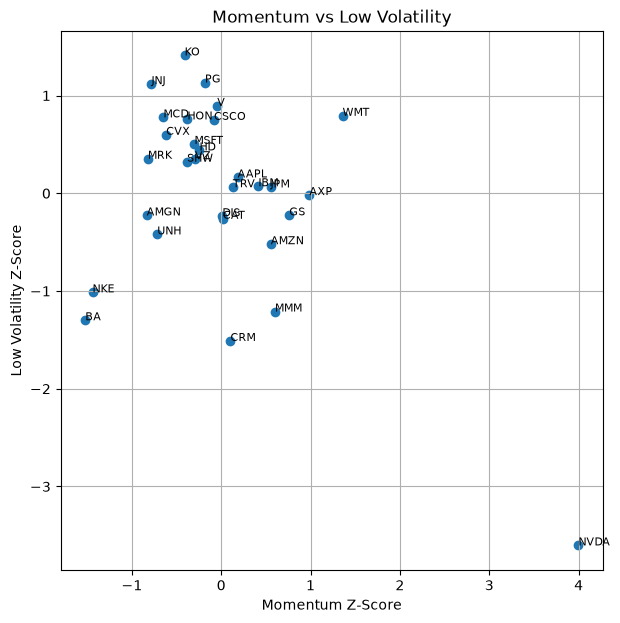

In [10]:
# Create a scatter plot to visualize the relationship between momentum and low volatility z-scores
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(
    multi_factor_table["momentum_z"],
    multi_factor_table["low_vol_z"]
)

for ticker in multi_factor_table.index:
    ax.text(
        multi_factor_table.loc[ticker, "momentum_z"],
        multi_factor_table.loc[ticker, "low_vol_z"],
        ticker,
        fontsize=8
    )

ax.set_xlabel("Momentum Z-Score")
ax.set_ylabel("Low Volatility Z-Score")
ax.set_title("Momentum vs Low Volatility")

ax.grid(True)

plt.show()

The Momentum and Low Volatility factors exhibited a moderate negative Pearson correlation (-0.495) but only a weak negative Spearman correlation (-0.220). This suggests that while high-momentum stocks tended to be more volatile in terms of their standardized values, the overall stock rankings produced by the two factors differed only modestly. Consequently, the factors contain partially distinct information, although combining them with equal weighting did not improve portfolio performance over the sample period.